In [ ]:
# ==========================================
# Deep Learning Lab - Experiment 2
# Task 1 : Dataset Exploration
# ==========================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# ==========================================
# Create folders to store outputs
# ==========================================

folders = [
    "outputs",
    "reports",
    "saved_models"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [ ]:
# ==========================================
# Global Plot Settings
# ==========================================

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 15
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["legend.fontsize"] = 15


In [ ]:
# ==========================================
# Load Fashion-MNIST Dataset
# ==========================================

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("=" * 60)
print("Fashion-MNIST Dataset Successfully Loaded")
print("=" * 60)

print(f"Training Images : {X_train.shape}")
print(f"Training Labels : {y_train.shape}")
print(f"Testing Images  : {X_test.shape}")
print(f"Testing Labels  : {y_test.shape}")

Fashion-MNIST Dataset Successfully Loaded
Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)


In [ ]:
# ==========================================
# Dataset Summary
# ==========================================

class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

summary = pd.DataFrame({
    "Attribute": [
        "Training Images",
        "Testing Images",
        "Image Size",
        "Number of Classes",
        "Pixel Value Range"
    ],
    "Value": [
        len(X_train),
        len(X_test),
        "28 × 28",
        len(class_names),
        "0 - 255"
    ]
})

print(summary)

           Attribute    Value
0    Training Images    60000
1     Testing Images    10000
2         Image Size  28 × 28
3  Number of Classes       10
4  Pixel Value Range  0 - 255


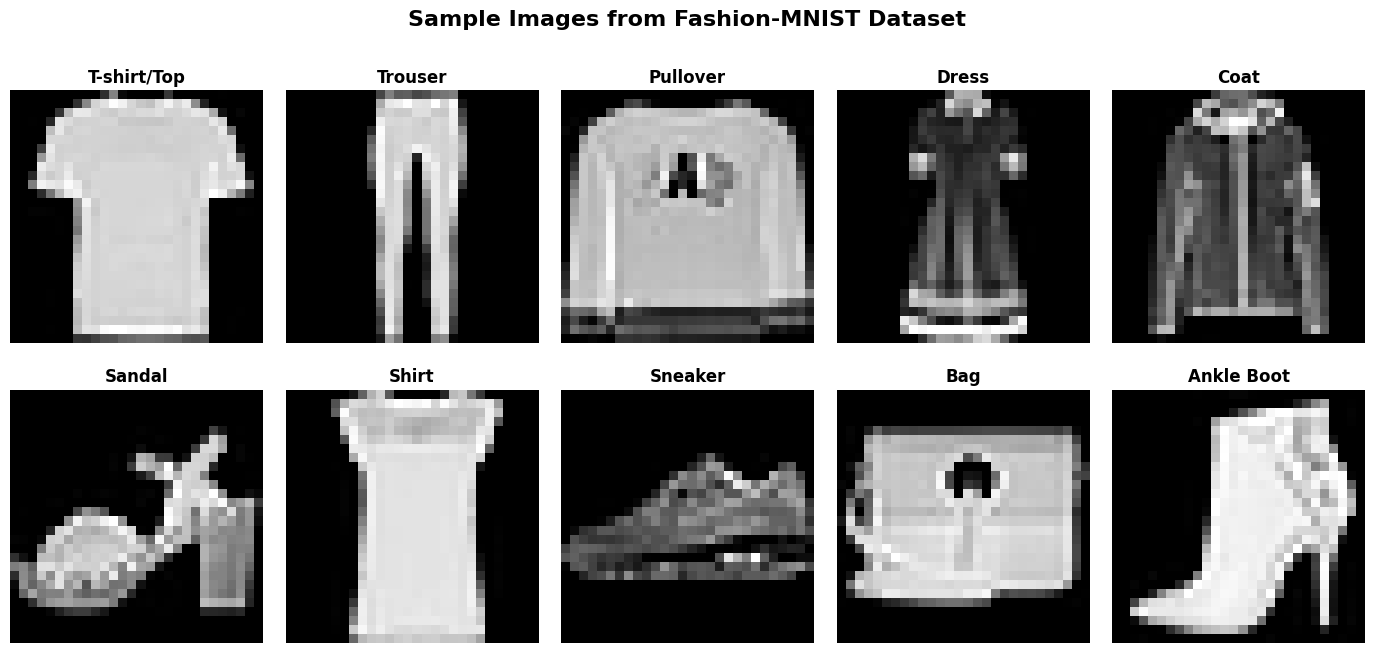

Figure saved as outputs/sample_images.eps


In [ ]:
# ==========================================
# Display One Random Sample From Each Class
# ==========================================

fig, axes = plt.subplots(2, 5, figsize=(14, 7))

for class_id, ax in enumerate(axes.flat):

    idx = np.random.choice(np.where(y_train == class_id)[0])

    ax.imshow(X_train[idx], cmap="gray")
    ax.set_title(class_names[class_id],
                 fontsize=12,
                 fontweight='bold')

    ax.axis("off")

plt.suptitle("Sample Images from Fashion-MNIST Dataset",
             fontsize=16,
             fontweight='bold')

plt.tight_layout()

plt.savefig(
    "outputs/sample_images.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Figure saved as outputs/sample_images.eps")

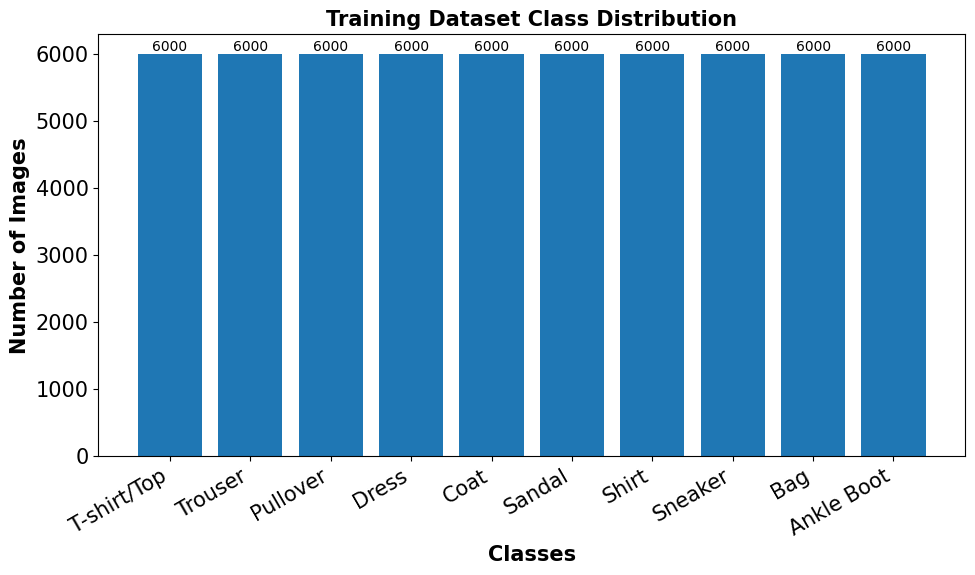

Figure saved as outputs/class_distribution.eps


In [ ]:
# ==========================================
# Class Distribution
# ==========================================

counts = np.bincount(y_train)

plt.figure(figsize=(10,6))

bars = plt.bar(class_names, counts)

plt.xticks(rotation=30, ha='right')

plt.xlabel("Classes",
           fontweight='bold')

plt.ylabel("Number of Images",
           fontweight='bold')

plt.title("Training Dataset Class Distribution",
          fontweight='bold')

# Add count labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 50,
             f"{height}",
             ha='center',
             fontsize=10)

plt.tight_layout()

plt.savefig(
    "outputs/class_distribution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Figure saved as outputs/class_distribution.eps")

In [ ]:
# ==========================================
# Task 2 : Data Preprocessing
# ==========================================

print("=" * 60)
print("DATA PREPROCESSING")
print("=" * 60)

# Store original shapes
train_original_shape = X_train.shape
test_original_shape = X_test.shape

print("\nOriginal Shapes")
print("------------------------------")
print(f"X_train : {train_original_shape}")
print(f"X_test  : {test_original_shape}")

DATA PREPROCESSING

Original Shapes
------------------------------
X_train : (60000, 28, 28)
X_test  : (10000, 28, 28)


In [ ]:
# ==========================================
# Flatten Images
# ==========================================

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("After Flattening")
print("------------------------------")
print(f"X_train_flat : {X_train_flat.shape}")
print(f"X_test_flat  : {X_test_flat.shape}")

After Flattening
------------------------------
X_train_flat : (60000, 784)
X_test_flat  : (10000, 784)


In [ ]:
# ==========================================
# Normalize Pixel Values
# ==========================================

X_train_flat = X_train_flat.astype("float32") / 255.0
X_test_flat = X_test_flat.astype("float32") / 255.0

print("Normalization Completed")
print("------------------------------")

print(f"Minimum Pixel Value : {X_train_flat.min():.3f}")
print(f"Maximum Pixel Value : {X_train_flat.max():.3f}")

Normalization Completed
------------------------------
Minimum Pixel Value : 0.000
Maximum Pixel Value : 1.000


In [ ]:
# ==========================================
# One-Hot Encoding
# ==========================================

from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("Label Encoding Completed")
print("------------------------------")

print(f"y_train_cat : {y_train_cat.shape}")
print(f"y_test_cat  : {y_test_cat.shape}")

Label Encoding Completed
------------------------------
y_train_cat : (60000, 10)
y_test_cat  : (10000, 10)


In [ ]:
# ==========================================
# Preprocessing Summary
# ==========================================

summary = pd.DataFrame({
    "Stage": [
        "Original Training Images",
        "Original Testing Images",
        "Flattened Training Data",
        "Flattened Testing Data",
        "Training Labels",
        "Testing Labels"
    ],
    "Shape": [
        str(train_original_shape),
        str(test_original_shape),
        str(X_train_flat.shape),
        str(X_test_flat.shape),
        str(y_train_cat.shape),
        str(y_test_cat.shape)
    ]
})

print(summary)

summary.to_csv(
    "reports/preprocessing_summary.csv",
    index=False
)

print("\nSummary saved to reports/preprocessing_summary.csv")

                      Stage            Shape
0  Original Training Images  (60000, 28, 28)
1   Original Testing Images  (10000, 28, 28)
2   Flattened Training Data     (60000, 784)
3    Flattened Testing Data     (10000, 784)
4           Training Labels      (60000, 10)
5            Testing Labels      (10000, 10)

Summary saved to reports/preprocessing_summary.csv


In [ ]:
# ==========================================
# Verification
# ==========================================

print("=" * 60)
print("PREPROCESSING VERIFICATION")
print("=" * 60)

print(f"Image Vector Length : {X_train_flat.shape[1]}")
print(f"Pixel Range         : {X_train_flat.min():.2f} to {X_train_flat.max():.2f}")
print(f"One-Hot Classes     : {y_train_cat.shape[1]}")

print("\nFirst 10 Normalized Pixel Values")
print("--------------------------------")
print(np.round(X_train_flat[0][:10], 3))

print("\nFirst One-Hot Encoded Label")
print("---------------------------")
print(y_train_cat[0])

PREPROCESSING VERIFICATION
Image Vector Length : 784
Pixel Range         : 0.00 to 1.00
One-Hot Classes     : 10

First 10 Normalized Pixel Values
--------------------------------
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

First One-Hot Encoded Label
---------------------------
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [ ]:
# ==========================================
# Task 3 : Model Construction
# Import Required Modules
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import plot_model

In [ ]:
# ==========================================
# Build Baseline MLP Model
# ==========================================

def build_baseline_model():

    model = Sequential(name="Baseline_MLP")

    # Input Layer
    model.add(Input(shape=(784,), name="Input_Layer"))

    # Hidden Layer 1
    model.add(Dense(
        units=128,
        activation='relu',
        name='Hidden_Layer_1'
    ))

    # Hidden Layer 2
    model.add(Dense(
        units=64,
        activation='relu',
        name='Hidden_Layer_2'
    ))

    # Output Layer
    model.add(Dense(
        units=10,
        activation='softmax',
        name='Output_Layer'
    ))

    return model

# Create the model
baseline_model = build_baseline_model()

In [ ]:
# ==========================================
# Display Model Summary
# ==========================================

baseline_model.summary()

Model: "Baseline_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==========================================
# Save Model Summary
# ==========================================

with open("reports/model_summary.txt", "w") as f:
    baseline_model.summary(
        print_fn=lambda x: f.write(x + "\n")
    )

print("Model summary saved to reports/model_summary.txt")

Model summary saved to reports/model_summary.txt


In [ ]:
# ==========================================
# Save Model Architecture Diagram
# ==========================================

try:

    plot_model(
        baseline_model,
        to_file="outputs/model_architecture.png",
        show_shapes=True,
        show_layer_names=True,
        dpi=300
    )

    print("Model architecture saved successfully.")

except Exception as e:

    print("Graphviz is not available.")
    print("Skipping architecture visualization.")

Model architecture saved successfully.


In [ ]:
# ==========================================
# Model Statistics
# ==========================================

trainable_params = baseline_model.count_params()

print("=" * 50)
print("MODEL INFORMATION")
print("=" * 50)

print(f"Total Trainable Parameters : {trainable_params:,}")

print("\nArchitecture")
print("----------------------------")
print("Input Layer   : 784 Neurons")
print("Hidden Layer1 : 128 Neurons (ReLU)")
print("Hidden Layer2 : 64 Neurons (ReLU)")
print("Output Layer  : 10 Neurons (Softmax)")

MODEL INFORMATION
Total Trainable Parameters : 109,386

Architecture
----------------------------
Input Layer   : 784 Neurons
Hidden Layer1 : 128 Neurons (ReLU)
Hidden Layer2 : 64 Neurons (ReLU)
Output Layer  : 10 Neurons (Softmax)


In [ ]:
# ==========================================
# Task 4 : Compile Baseline Model
# ==========================================

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Baseline model compiled successfully.")

Baseline model compiled successfully.


In [ ]:
# ==========================================
# Train Baseline Model
# ==========================================

import time

start_time = time.time()

history = baseline_model.fit(
    X_train_flat,
    y_train_cat,
    validation_split=0.20,
    epochs=20,
    batch_size=32,
    verbose=1,
    shuffle=True
)

end_time = time.time()

baseline_training_time = end_time - start_time

print(f"\nTraining Time : {baseline_training_time:.2f} seconds")

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8177 - loss: 0.5109 - val_accuracy: 0.8559 - val_loss: 0.4044
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8641 - loss: 0.3735 - val_accuracy: 0.8683 - val_loss: 0.3629
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8768 - loss: 0.3359 - val_accuracy: 0.8679 - val_loss: 0.3590
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8841 - loss: 0.3113 - val_accuracy: 0.8697 - val_loss: 0.3623
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8910 - loss: 0.2924 - val_accuracy: 0.8742 - val_loss: 0.3563
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8977 - loss: 0.2744 - val_accuracy: 0.8749 - val_loss: 0.3583
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9018 - loss: 0.2627 - val_accuracy: 0.8793 - val_loss: 0.3425
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9070 - loss: 0.2488

In [ ]:
# ==========================================
# Save Baseline Model
# ==========================================

baseline_model.save("saved_models/baseline_model.keras")

print("Baseline model saved successfully.")

Baseline model saved successfully.


In [ ]:
# ==========================================
# Save Training History
# ==========================================

history_df = pd.DataFrame(history.history)

history_df.to_csv(
    "reports/baseline_training_history.csv",
    index=False
)

print("Training history saved.")

Training history saved.


In [ ]:
# ==========================================
# Final Training Statistics
# ==========================================

print("=" * 60)
print("BASELINE MODEL TRAINING COMPLETED")
print("=" * 60)

print(f"Epochs                : 20")
print(f"Batch Size            : 32")
print(f"Optimizer             : Adam")
print(f"Loss Function         : Categorical Crossentropy")

print(f"\nFinal Training Accuracy   : {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {history.history['val_accuracy'][-1]:.4f}")

print(f"\nTraining Time : {baseline_training_time:.2f} seconds")

BASELINE MODEL TRAINING COMPLETED
Epochs                : 20
Batch Size            : 32
Optimizer             : Adam
Loss Function         : Categorical Crossentropy

Final Training Accuracy   : 0.9374
Final Validation Accuracy : 0.8781

Training Time : 172.59 seconds


In [ ]:
# ==========================================
# Task 5 : Model Evaluation
# Import Required Libraries
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
# ==========================================
# Predict Test Data
# ==========================================

y_pred_prob = baseline_model.predict(X_test_flat, verbose=0)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert one-hot encoded labels back to integers
y_true = np.argmax(y_test_cat, axis=1)

print("Prediction completed successfully.")

Prediction completed successfully.


In [ ]:
# ==========================================
# Compute Evaluation Metrics
# ==========================================

baseline_accuracy = accuracy_score(y_true, y_pred)

baseline_precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

baseline_recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

baseline_f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("="*50)
print("BASELINE MODEL PERFORMANCE")
print("="*50)

print(f"Accuracy  : {baseline_accuracy:.4f}")
print(f"Precision : {baseline_precision:.4f}")
print(f"Recall    : {baseline_recall:.4f}")
print(f"F1 Score  : {baseline_f1:.4f}")

BASELINE MODEL PERFORMANCE
Accuracy  : 0.8712
Precision : 0.8746
Recall    : 0.8712
F1 Score  : 0.8710


In [ ]:
# ==========================================
# Save Evaluation Metrics
# ==========================================

metrics_df = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (s)"
    ],
    "Baseline":[
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_training_time
    ]
})

metrics_df.to_csv(
    "reports/baseline_metrics.csv",
    index=False
)

print("Metrics saved successfully.")

Metrics saved successfully.


In [ ]:
# ==========================================
# Classification Report
# ==========================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

 T-shirt/Top     0.8715    0.7120    0.7837      1000
     Trouser     0.9898    0.9680    0.9788      1000
    Pullover     0.8231    0.7770    0.7994      1000
       Dress     0.8746    0.8860    0.8803      1000
        Coat     0.7152    0.8740    0.7867      1000
      Sandal     0.9874    0.9380    0.9621      1000
       Shirt     0.6724    0.6650    0.6687      1000
     Sneaker     0.9146    0.9740    0.9433      1000
         Bag     0.9429    0.9750    0.9587      1000
  Ankle Boot     0.9545    0.9430    0.9487      1000

    accuracy                         0.8712     10000
   macro avg     0.8746    0.8712    0.8710     10000
weighted avg     0.8746    0.8712    0.8710     10000



In [ ]:
# ==========================================
# Save Classification Report
# ==========================================

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

report_df.to_csv(
    "reports/classification_report.csv"
)

print("Classification report saved.")

Classification report saved.


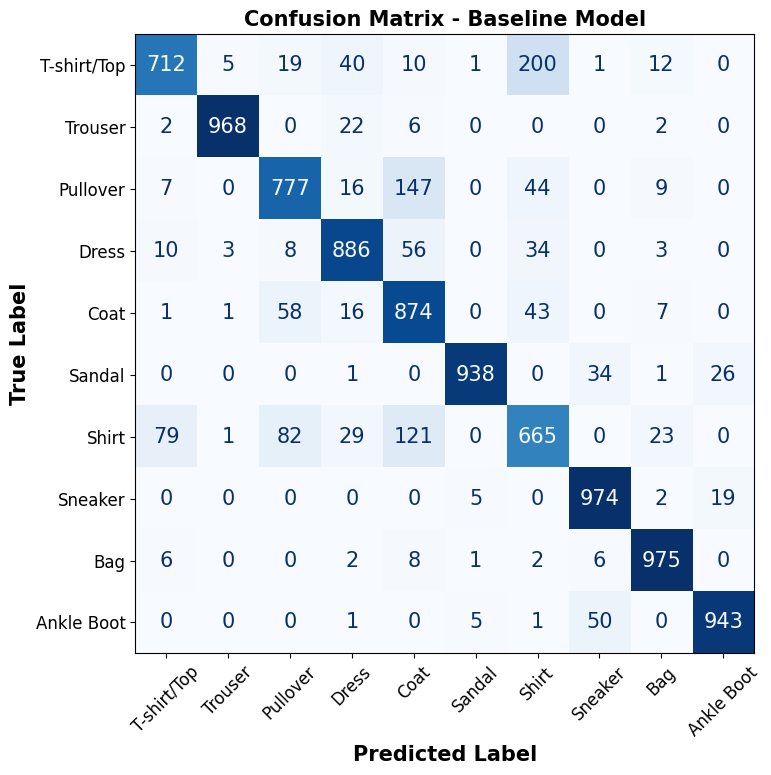

Confusion Matrix saved successfully.


In [ ]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title(
    "Confusion Matrix - Baseline Model",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel(
    "Predicted Label",
    fontsize=15,
    fontweight='bold'
)

plt.ylabel(
    "True Label",
    fontsize=15,
    fontweight='bold'
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig(
    "outputs/confusion_matrix.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()

print("Confusion Matrix saved successfully.")

In [ ]:
# ==========================================
# Final Evaluation Summary
# ==========================================

evaluation_summary = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value":[
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ]
})

display(evaluation_summary)

,Metric,Value
0,Accuracy,0.871200
1,Precision,0.874591
2,Recall,0.871200
3,F1 Score,0.871028


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

def build_model(
    hidden_layers=2,
    hidden_neurons=128,
    activation='relu',
    optimizer='adam',
    learning_rate=0.001,
    dropout_rate=0.0
):

    model = Sequential(name="MLP_Model")

    model.add(Input(shape=(784,), name="Input_Layer"))

    for i in range(hidden_layers):
        neurons = max(hidden_neurons // (2 ** i), 16)

        model.add(Dense(
            units=neurons,
            activation=activation,
            name=f"Hidden_Layer_{i+1}"
        ))

        if dropout_rate > 0:
            model.add(Dropout(
                dropout_rate,
                name=f"Dropout_{i+1}"
            ))

    model.add(Dense(
        10,
        activation="softmax",
        name="Output_Layer"
    ))

    optimizer_dict = {
        "adam": Adam(learning_rate=learning_rate),
        "sgd": SGD(learning_rate=learning_rate),
        "rmsprop": RMSprop(learning_rate=learning_rate)
    }

    model.compile(
        optimizer=optimizer_dict[optimizer],
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
import inspect

print(inspect.getsource(build_model))

def build_model(
    hidden_layers=2,
    hidden_neurons=128,
    activation='relu',
    optimizer='adam',
    learning_rate=0.001,
    dropout_rate=0.0
):

    model = Sequential(name="MLP_Model")

    model.add(Input(shape=(784,), name="Input_Layer"))

    for i in range(hidden_layers):
        neurons = max(hidden_neurons // (2 ** i), 16)

        model.add(Dense(
            units=neurons,
            activation=activation,
            name=f"Hidden_Layer_{i+1}"
        ))

        if dropout_rate > 0:
            model.add(Dropout(
                dropout_rate,
                name=f"Dropout_{i+1}"
            ))

    model.add(Dense(
        10,
        activation="softmax",
        name="Output_Layer"
    ))

    optimizer_dict = {
        "adam": Adam(learning_rate=learning_rate),
        "sgd": SGD(learning_rate=learning_rate),
        "rmsprop": RMSprop(learning_rate=learning_rate)
    }

    model.compile(
        optimizer=optimizer_dict[optimizer],
        loss="categorica

In [ ]:
# ==========================================
# Install SciKeras (Google Colab)
# ==========================================

try:
    import scikeras
    print("SciKeras is already installed.")
except ImportError:
    !pip install -q scikeras
    print("SciKeras installed successfully.")

SciKeras is already installed.


In [ ]:
# ==========================================
# Hyperparameter Optimization
# Required Imports
# ==========================================

from scikeras.wrappers import KerasClassifier

from sklearn.model_selection import RandomizedSearchCV

from scipy.stats import randint

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ==========================================
# Wrap Keras Model
# ==========================================

mlp_classifier = KerasClassifier(
    model=build_model,
    verbose=0
)

In [ ]:
# ==========================================
# Hyperparameter Search Space
# ==========================================

param_dist = {

    "model__hidden_layers":[1,2,3],

    "model__hidden_neurons":[32,64,128,256],

    "model__learning_rate":[
        0.1,
        0.01,
        0.001
    ],

    "model__optimizer":[
        "adam",
        "sgd",
        "rmsprop"
    ],

    "model__activation":[
        "relu",
        "tanh",
        "sigmoid"
    ],

    "model__dropout_rate":[
        0.0,
        0.2,
        0.5
    ],

    "batch_size":[
        16,
        32,
        64,
        128
    ],

    "epochs":[
        10,
        20,
        30
    ]

}

In [ ]:
# ==========================================
# Randomized Search
# ==========================================

random_search = RandomizedSearchCV(

    estimator=mlp_classifier,
    param_distributions=param_dist,
    n_iter=8,
    cv=5,
    scoring="accuracy",
    random_state=42,
    verbose=2,
    n_jobs=1,
    return_train_score=True,
    error_score="raise"

)

In [ ]:
!pip install -q --upgrade scikit-learn scikeras

In [ ]:
# ==========================================
# Start Hyperparameter Search
# ==========================================

import time

print("="*60)
print("STARTING RANDOMIZED SEARCH")
print("="*60)

search_start = time.time()

random_search.fit(
    X_train_flat,
    y_train_cat
)

search_end = time.time()

search_time = search_end-search_start

print("\nSearch Completed!")

print(f"Total Search Time : {search_time:.2f} seconds")

STARTING RANDOMIZED SEARCH
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=sgd; total time= 1.6min
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=sgd; total time= 1.3min
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=sgd; total time= 1.3min
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=sgd; total time= 1.2min
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden

In [ ]:
# ==========================================
# Retrieve the Best Model
# ==========================================

best_params = random_search.best_params_

print("=" * 60)
print("BEST HYPERPARAMETERS")
print("=" * 60)

for key, value in best_params.items():
    print(f"{key:<30}: {value}")

print(f"\nBest Cross Validation Accuracy : {random_search.best_score_:.4f}")

BEST HYPERPARAMETERS
model__optimizer              : rmsprop
model__learning_rate          : 0.001
model__hidden_neurons         : 128
model__hidden_layers          : 3
model__dropout_rate           : 0.2
model__activation             : tanh
epochs                        : 30
batch_size                    : 32

Best Cross Validation Accuracy : 0.8864


In [ ]:
# ==========================================
# Save Best Hyperparameters
# ==========================================

best_params_df = pd.DataFrame(
    list(best_params.items()),
    columns=["Hyperparameter", "Best Value"]
)

best_params_df.to_csv(
    "reports/best_hyperparameters.csv",
    index=False
)

print("Best hyperparameters saved successfully.")

Best hyperparameters saved successfully.


In [ ]:
# ==========================================
# Build Optimized Model
# ==========================================

optimized_model = build_model(

    hidden_layers=best_params["model__hidden_layers"],

    hidden_neurons=best_params["model__hidden_neurons"],

    activation=best_params["model__activation"],

    optimizer=best_params["model__optimizer"],

    learning_rate=best_params["model__learning_rate"],

    dropout_rate=best_params["model__dropout_rate"]

)

print("Optimized model created successfully.")

Optimized model created successfully.


In [ ]:
# ==========================================
# Train Optimized Model
# ==========================================

import time

start_time = time.time()

optimized_history = optimized_model.fit(

    X_train_flat,
    y_train_cat,

    validation_split=0.20,

    epochs=best_params["epochs"],

    batch_size=best_params["batch_size"],

    verbose=1,

    shuffle=True

)

end_time = time.time()

optimized_training_time = end_time - start_time

print(f"\nTraining Time : {optimized_training_time:.2f} seconds")

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.7793 - loss: 0.6383 - val_accuracy: 0.8413 - val_loss: 0.4468
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8306 - loss: 0.4858 - val_accuracy: 0.8512 - val_loss: 0.4159
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.8432 - loss: 0.4488 - val_accuracy: 0.8646 - val_loss: 0.3840
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8502 - loss: 0.4290 - val_accuracy: 0.8654 - val_loss: 0.3827
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8572 - loss: 0.4117 - val_accuracy: 0.8636 - val_loss: 0.3839
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8613 - loss: 0.4009 - val_accuracy: 0.8686 - val_loss: 0.3790
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8642 - loss: 0.3894 - val_accuracy: 0.8711 - val_loss: 0.3706
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8669 - loss: 0.379

In [ ]:
# ==========================================
# Save Optimized Model
# ==========================================

optimized_model.save(
    "saved_models/optimized_model.keras"
)

print("Optimized model saved successfully.")

Optimized model saved successfully.


In [ ]:
# ==========================================
# Save Optimized Training History
# ==========================================

optimized_history_df = pd.DataFrame(
    optimized_history.history
)

optimized_history_df.to_csv(
    "reports/optimized_training_history.csv",
    index=False
)

print("Training history saved.")

Training history saved.


In [ ]:
print(best_params)

{'model__optimizer': 'rmsprop', 'model__learning_rate': 0.001, 'model__hidden_neurons': 128, 'model__hidden_layers': 3, 'model__dropout_rate': 0.2, 'model__activation': 'tanh', 'epochs': 30, 'batch_size': 32}


In [ ]:
# ==========================================
# Train Optimized Model
# ==========================================

import time

start_time = time.time()

optimized_history = optimized_model.fit(
    X_train_flat,
    y_train_cat,
    validation_split=0.20,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    shuffle=True,
    verbose=1
)

optimized_training_time = time.time() - start_time

print(f"\nTraining Time : {optimized_training_time:.2f} seconds")

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8944 - loss: 0.3038 - val_accuracy: 0.8806 - val_loss: 0.3516
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8973 - loss: 0.2982 - val_accuracy: 0.8827 - val_loss: 0.3542
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8969 - loss: 0.2973 - val_accuracy: 0.8872 - val_loss: 0.3427
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8983 - loss: 0.2924 - val_accuracy: 0.8822 - val_loss: 0.3523
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8969 - loss: 0.2945 - val_accuracy: 0.8856 - val_loss: 0.3433
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8992 - loss: 0.2887 - val_accuracy: 0.8817 - val_loss: 0.3617
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8983 - loss: 0.2917 - val_accuracy: 0.8832 - val_loss: 0.3557
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8987 - loss: 0.2909 -

In [ ]:
# ==========================================
# Save Optimized Model
# ==========================================

optimized_model.save("saved_models/optimized_model.keras")

print("Optimized model saved successfully.")

Optimized model saved successfully.


In [ ]:
# ==========================================
# Save Training History
# ==========================================

optimized_history_df = pd.DataFrame(optimized_history.history)

optimized_history_df.to_csv(
    "reports/optimized_training_history.csv",
    index=False
)

print("Training history saved.")

Training history saved.


In [ ]:
# ==========================================
# Predictions
# ==========================================

y_pred_prob_opt = optimized_model.predict(X_test_flat)

y_pred_opt = np.argmax(y_pred_prob_opt, axis=1)

y_true_opt = np.argmax(y_test_cat, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
# ==========================================
# Evaluation Metrics
# ==========================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

opt_accuracy = accuracy_score(y_true_opt, y_pred_opt)

opt_precision = precision_score(
    y_true_opt,
    y_pred_opt,
    average="weighted"
)

opt_recall = recall_score(
    y_true_opt,
    y_pred_opt,
    average="weighted"
)

opt_f1 = f1_score(
    y_true_opt,
    y_pred_opt,
    average="weighted"
)

print("Accuracy :", opt_accuracy)
print("Precision:", opt_precision)
print("Recall   :", opt_recall)
print("F1 Score :", opt_f1)

Accuracy : 0.874
Precision: 0.8821833794654247
Recall   : 0.874
F1 Score : 0.8757774945712672


In [ ]:
# ==========================================
# Save Optimized Metrics
# ==========================================

optimized_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [
        opt_accuracy,
        opt_precision,
        opt_recall,
        opt_f1
    ]
})

optimized_metrics.to_csv(
    "reports/optimized_metrics.csv",
    index=False
)

optimized_metrics

,Metric,Value
0,Accuracy,0.874000
1,Precision,0.882183
2,Recall,0.874000
3,F1 Score,0.875777


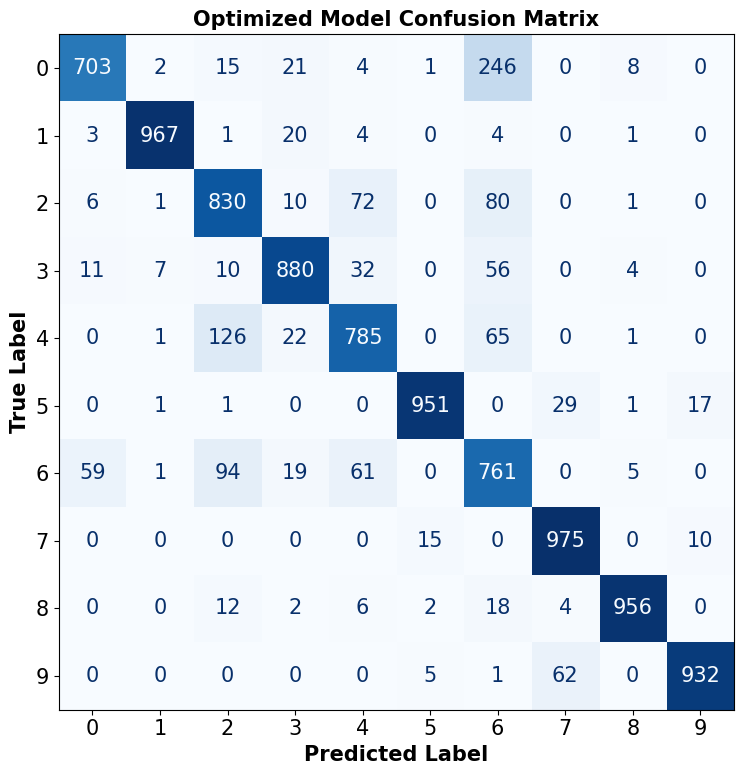

In [ ]:
# ==========================================
# Optimized Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true_opt, y_pred_opt)

fig, ax = plt.subplots(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Optimized Model Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted Label", fontweight="bold")
plt.ylabel("True Label", fontweight="bold")

plt.tight_layout()

plt.savefig(
    "outputs/optimized_confusion_matrix.eps",
    dpi=600,
    format="eps"
)

plt.show()

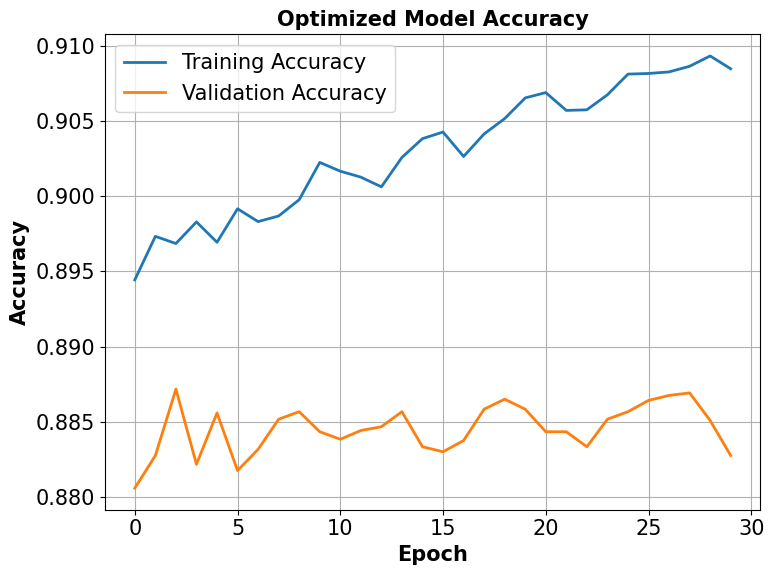

In [ ]:
# ==========================================
# Accuracy Curve
# ==========================================

plt.figure(figsize=(8,6))

plt.plot(
    optimized_history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    optimized_history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title("Optimized Model Accuracy", fontweight="bold")
plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Accuracy", fontweight="bold")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "outputs/optimized_accuracy_curve.eps",
    dpi=600,
    format="eps"
)

plt.show()

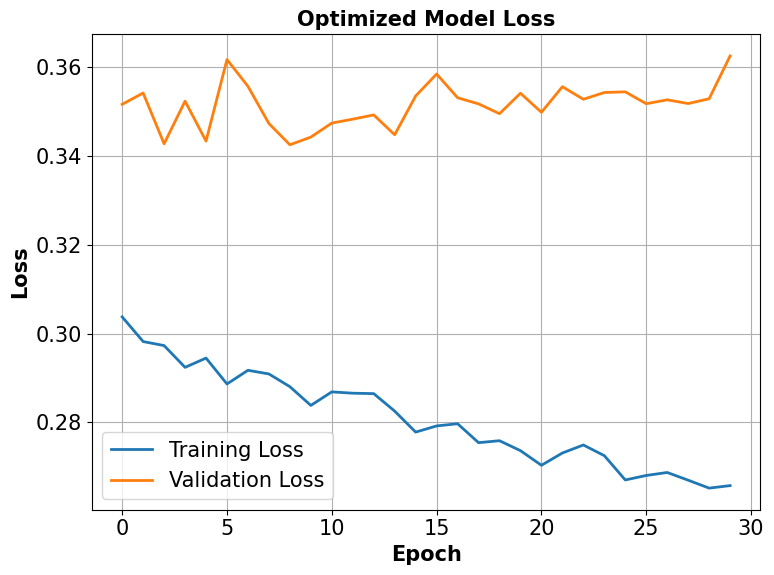

In [ ]:
# ==========================================
# Loss Curve
# ==========================================

plt.figure(figsize=(8,6))

plt.plot(
    optimized_history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    optimized_history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("Optimized Model Loss", fontweight="bold")
plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Loss", fontweight="bold")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "outputs/optimized_loss_curve.eps",
    dpi=600,
    format="eps"
)

plt.show()

In [ ]:
# ==========================================
# Baseline vs Optimized Comparison
# ==========================================

comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (s)"
    ],

    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_training_time
    ],

    "Optimized": [
        opt_accuracy,
        opt_precision,
        opt_recall,
        opt_f1,
        optimized_training_time
    ]

})

comparison

,Metric,Baseline,Optimized
0,Accuracy,0.871200,0.874000
1,Precision,0.874591,0.882183
2,Recall,0.871200,0.874000
3,F1 Score,0.871028,0.875777
4,Training Time (s),172.593102,232.498533


In [ ]:
comparison.to_csv(
    "reports/model_comparison.csv",
    index=False
)

print("Comparison saved.")

Comparison saved.


In [ ]:
print("="*60)
print("DEEP LEARNING LAB EXPERIMENT COMPLETED")
print("="*60)

print("\nGenerated Files")

print("\nOutputs Folder")
print("----------------")
print("sample_images.eps")
print("class_distribution.eps")
print("confusion_matrix.eps")
print("optimized_confusion_matrix.eps")
print("optimized_accuracy_curve.eps")
print("optimized_loss_curve.eps")

print("\nReports Folder")
print("----------------")
print("preprocessing_summary.csv")
print("baseline_training_history.csv")
print("optimized_training_history.csv")
print("baseline_metrics.csv")
print("optimized_metrics.csv")
print("classification_report.csv")
print("best_hyperparameters.csv")
print("model_comparison.csv")
print("model_summary.txt")

print("\nSaved Models")
print("----------------")
print("baseline_model.keras")
print("optimized_model.keras")

print("\nNotebook executed successfully.")

DEEP LEARNING LAB EXPERIMENT COMPLETED

Generated Files

Outputs Folder
----------------
sample_images.eps
class_distribution.eps
confusion_matrix.eps
optimized_confusion_matrix.eps
optimized_accuracy_curve.eps
optimized_loss_curve.eps

Reports Folder
----------------
preprocessing_summary.csv
baseline_training_history.csv
optimized_training_history.csv
baseline_metrics.csv
optimized_metrics.csv
classification_report.csv
best_hyperparameters.csv
model_comparison.csv
model_summary.txt

Saved Models
----------------
baseline_model.keras
optimized_model.keras

Notebook executed successfully.


In [ ]:
%who

Adam	 ConfusionMatrixDisplay	 Dense	 Dropout	 Input	 KerasClassifier	 RMSprop	 RandomizedSearchCV	 SEED	 
SGD	 Sequential	 X_test	 X_test_flat	 X_train	 X_train_flat	 accuracy_score	 ax	 axes	 
bar	 bars	 baseline_accuracy	 baseline_f1	 baseline_model	 baseline_precision	 baseline_recall	 baseline_training_time	 best_params	 
best_params_df	 build_baseline_model	 build_model	 class_id	 class_names	 classification_report	 cm	 comparison	 confusion_matrix	 
counts	 disp	 end_time	 evaluation_summary	 f	 f1_score	 fashion_mnist	 fig	 folder	 
folders	 height	 history	 history_df	 idx	 inspect	 key	 metrics_df	 mlp_classifier	 
np	 opt_accuracy	 opt_f1	 opt_precision	 opt_recall	 optimized_history	 optimized_history_df	 optimized_metrics	 optimized_model	 
optimized_training_time	 os	 param_dist	 pd	 plot_model	 plt	 precision_score	 randint	 random	 
random_search	 recall_score	 report	 report_df	 report_dict	 scikeras	 search_end	 search_start	 search_time	 
start_time	 summary	 test_ori

In [ ]:
!pip install -q --upgrade scikit-learn scikeras

In [ ]:
import shutil

shutil.make_archive("DeepLearningLab_2", "zip", ".")

print("ZIP created!")

ZIP created!


In [ ]:
print(random_search.best_score_)

0.8863666666666667


In [ ]:
plt.savefig("outputs/optimized_confusion_matrix.png", dpi=600, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [ ]:
# ==========================================
# Hyperparameter Search Results
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Load best hyperparameter search results
best_params = pd.read_csv("reports/best_hyperparameters.csv")

# Create a dataframe for plotting
plot_df = pd.DataFrame({
    "Parameter": [
        "Hidden Layers",
        "Hidden Neurons",
        "Learning Rate",
        "Batch Size",
        "Optimizer",
        "Activation",
        "Epochs",
        "Dropout"
    ],
    "Value": [
        str(best_params["Hidden Layers"][0]),
        str(best_params["Hidden Neurons"][0]),
        str(best_params["Learning Rate"][0]),
        str(best_params["Batch Size"][0]),
        best_params["Optimizer"][0],
        best_params["Activation"][0],
        str(best_params["Epochs"][0]),
        str(best_params["Dropout"][0])
    ]
})

plt.figure(figsize=(12,6))
plt.axis("off")

table = plt.table(
    cellText=plot_df.values,
    colLabels=plot_df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1.2,2)

plt.title(
    "Best Hyperparameter Configuration Obtained Using RandomizedSearchCV",
    fontsize=15,
    fontweight='bold'
)

plt.savefig(
    "outputs/hyperparameter_search_results.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

KeyError: 'Hidden Layers'

In [ ]:
import pandas as pd

best_params = pd.read_csv("reports/best_hyperparameters.csv")

print(best_params)
print(best_params.columns)

          Hyperparameter Best Value
0       model__optimizer    rmsprop
1   model__learning_rate      0.001
2  model__hidden_neurons        128
3   model__hidden_layers          3
4    model__dropout_rate        0.2
5      model__activation       tanh
6                 epochs         30
7             batch_size         32
Index(['Hyperparameter', 'Best Value'], dtype='object')


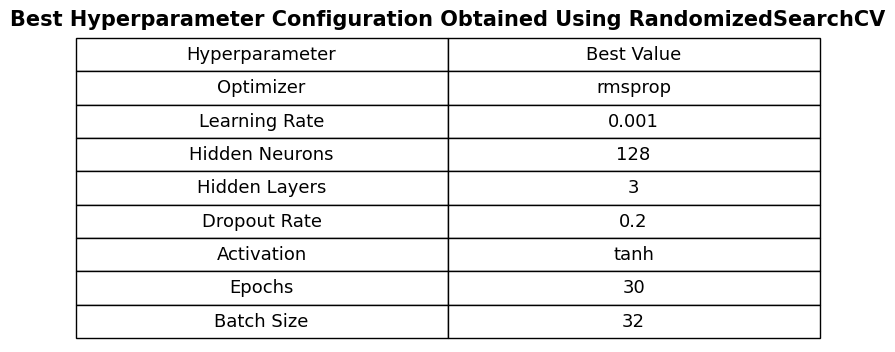

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
best_params = pd.read_csv("reports/best_hyperparameters.csv")

# Make parameter names readable
best_params["Hyperparameter"] = (
    best_params["Hyperparameter"]
    .str.replace("model__", "", regex=False)
    .str.replace("_", " ")
    .str.title()
)

plt.figure(figsize=(8,4))
plt.axis("off")

table = plt.table(
    cellText=best_params.values,
    colLabels=best_params.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1.2, 2)

plt.title(
    "Best Hyperparameter Configuration Obtained Using RandomizedSearchCV",
    fontsize=15,
    fontweight="bold"
)

plt.savefig(
    "outputs/hyperparameter_search_results.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================
# Accuracy Comparison
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.read_csv("reports/model_comparison.csv")

plt.figure(figsize=(7,6))

bars = plt.bar(
    comparison["Model"],
    comparison["Accuracy"],
)

plt.title(
    "Baseline vs Optimized Model Accuracy",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel(
    "Model",
    fontsize=15,
    fontweight='bold'
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=15,
    fontweight='bold'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.05,
        f"{height:.2f}",
        ha='center',
        fontsize=13,
        fontweight='bold'
    )

plt.savefig(
    "outputs/model_accuracy_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

KeyError: 'Model'

<Figure size 700x600 with 0 Axes>

In [ ]:
import pandas as pd

best_params = pd.read_csv("reports/model_comparison.csv")

print(best_params)
print(best_params.columns)

              Metric    Baseline   Optimized
0           Accuracy    0.871200    0.874000
1          Precision    0.874591    0.882183
2             Recall    0.871200    0.874000
3           F1 Score    0.871028    0.875777
4  Training Time (s)  172.593102  232.498533
Index(['Metric', 'Baseline', 'Optimized'], dtype='object')


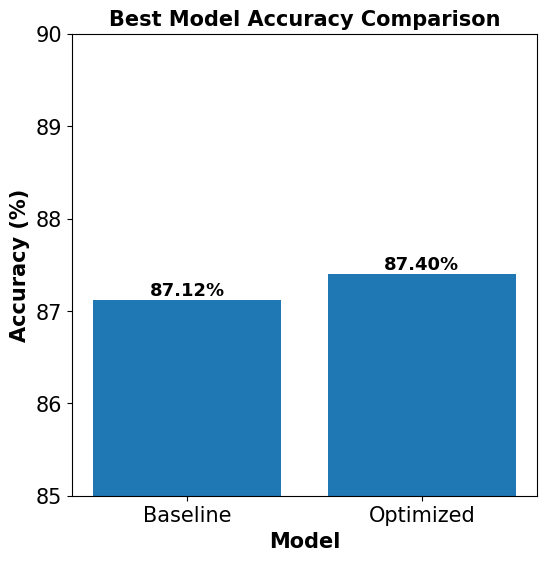

In [ ]:
# ==========================================
# Best Model Accuracy Comparison
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Load comparison results
comparison = pd.read_csv("reports/model_comparison.csv")

# Extract only the Accuracy row
accuracy = comparison[comparison["Metric"] == "Accuracy"]

baseline = accuracy["Baseline"].values[0] * 100
optimized = accuracy["Optimized"].values[0] * 100

plt.figure(figsize=(6,6))

bars = plt.bar(
    ["Baseline", "Optimized"],
    [baseline, optimized]
)

plt.title(
    "Best Model Accuracy Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Model",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=15,
    fontweight="bold"
)

plt.ylim(85, 90)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f"{height:.2f}%",
        ha="center",
        fontsize=13,
        fontweight="bold"
    )

plt.savefig(
    "outputs/model_accuracy_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import shutil

shutil.make_archive("DeepLearningLab_2", "zip", ".")

print("ZIP created!")

ZIP created!
